# 06 — Frozen Final Evaluation

This notebook performs the **final internal-test evaluation** for the Efficient Multi-Scale Visual Saliency Prediction project.

It compares:

- **MeanMap** — non-learned centre-prior baseline;
- **Light-S** — MobileNetV2 with the single-scale decoder;
- **Light-M** — MobileNetV2 with the compact multi-scale decoder;
- **Heavy-M** — ResNet-18 with the same compact multi-scale decoder.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os

REPO_URL = "https://github.com/RicoDalB/efficient-saliency-prediction.git"
REPO_ROOT = Path("/content/efficient-saliency-prediction")

DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")
DRIVE_DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

CHECKPOINT_ROOT = DRIVE_ROOT / "checkpoints"
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
METRICS_ROOT = OUTPUT_ROOT / "metrics"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
PREDICTION_ROOT = OUTPUT_ROOT / "predictions" / "final_selected"
LOG_ROOT = DRIVE_ROOT / "logs"
RUN_NOTE_ROOT = LOG_ROOT / "run_notes"
SPLIT_ROOT = DRIVE_ROOT / "splits"

SEED = 42
DEFAULT_OUTPUT_SIZE = (192, 256)
DEFAULT_DECODER_CHANNELS = 32

EVAL_BATCH_SIZE = 8
NUM_WORKERS = min(4, os.cpu_count() or 2)
PREFETCH_FACTOR = 2
USE_AMP = True

OFFCENTRE_FRACTION = 0.25

LATENCY_WARMUP = 30
LATENCY_RUNS = 200
LATENCY_REPEATS = 3
LATENCY_THREADS = 1

print("Drive root:", DRIVE_ROOT)
print("Evaluation batch size:", EVAL_BATCH_SIZE)
print("DataLoader workers:", NUM_WORKERS)

Drive root: /content/drive/MyDrive/saliency_project
Evaluation batch size: 8
DataLoader workers: 2


In [ ]:
import subprocess

if (REPO_ROOT / ".git").is_dir():
    print("Refreshing the temporary repository clone...")
    subprocess.run(
        ["git", "-C", str(REPO_ROOT), "reset", "--hard", "HEAD"],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(REPO_ROOT), "pull", "--ff-only"],
        check=True,
    )
else:
    print("Cloning the repository...")
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_ROOT)],
        check=True,
    )

commit_hash = subprocess.run(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"],
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

print("Repository:", REPO_ROOT)
print("Git commit:", commit_hash)

Cloning the repository...
Repository: /content/efficient-saliency-prediction
Git commit: d488e600dea2dfe5d3917e242ecf0ec4d9115c79


In [ ]:
MODELS_SOURCE_PATH = REPO_ROOT / "src" / "models.py"
source_patch_notes = []

if not MODELS_SOURCE_PATH.is_file():
    raise FileNotFoundError(f"Missing source file: {MODELS_SOURCE_PATH}")

models_source = MODELS_SOURCE_PATH.read_text(encoding="utf-8")

known_source_fixes = {
    "def farward(self, x: Tensor)": "def forward(self, x: Tensor)",
    "def _unsample_add(self, x: Tensor, lateral: Tensor)": (
        "def _upsample_add(self, x: Tensor, lateral: Tensor)"
    ),
}

for incorrect_text, corrected_text in known_source_fixes.items():
    if incorrect_text in models_source:
        models_source = models_source.replace(incorrect_text, corrected_text)
        source_patch_notes.append(f"{incorrect_text} -> {corrected_text}")

if source_patch_notes:
    MODELS_SOURCE_PATH.write_text(models_source, encoding="utf-8")
    print("Applied temporary corrections:")
    for note in source_patch_notes:
        print(" -", note)
else:
    print("The source contract is already correct.")

Applied temporary corrections:
 - def farward(self, x: Tensor) -> def forward(self, x: Tensor)


In [ ]:
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "thop"],
    check=True,
)

print("THOP installed.")

THOP installed.


In [ ]:
import hashlib
import importlib
import json
import math
import platform
import random
import shutil
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision

from IPython.display import display, Markdown
from torch.utils.data import DataLoader, Subset

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.data as data_module
import src.losses_metrics as losses_module
import src.models as models_module
import src.train_eval as train_eval_module

importlib.reload(data_module)
importlib.reload(losses_module)
importlib.reload(models_module)
importlib.reload(train_eval_module)

from src.data import IMAGENET_MEAN, IMAGENET_STD, SaliconDataset
from src.losses_metrics import (
    correlation_coefficient,
    kld_divergence,
    similarity_score,
    spatial_softmax,
    validate_spatial_distribution,
)
from src.models import build_model, parameter_summary
from src.train_eval import evaluate_model, load_checkpoint

print("Shared modules imported successfully.")

Shared modules imported successfully.


In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")

print("Device:", DEVICE)
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB",
    )

Device: cuda
Python: 3.12.13
PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
GPU: Tesla T4
GPU memory: 14.56 GB


In [ ]:
FINAL_METRICS_PATH = METRICS_ROOT / "final_metrics.csv"
EFFICIENCY_METRICS_PATH = METRICS_ROOT / "efficiency_metrics.csv"
CENTRE_BIAS_METRICS_PATH = METRICS_ROOT / "centre_bias_metrics.csv"
FINAL_REPORT_TABLE_PATH = METRICS_ROOT / "final_report_table.csv"
PAIRED_COMPARISON_PATH = METRICS_ROOT / "paired_model_comparison.csv"
OFFCENTRE_GEOMETRY_PATH = METRICS_ROOT / "offcentre_ground_truth_geometry.csv"
SELECTED_EXAMPLES_PATH = METRICS_ROOT / "selected_qualitative_examples.csv"

FINAL_METRIC_FIGURE_PATH = FIGURE_ROOT / "final_metric_comparison.png"
FINAL_METRIC_FIGURE_PDF_PATH = FIGURE_ROOT / "final_metric_comparison.pdf"
TRAINING_CURVES_FIGURE_PATH = FIGURE_ROOT / "final_training_curves.png"
TRAINING_CURVES_FIGURE_PDF_PATH = FIGURE_ROOT / "final_training_curves.pdf"
CENTRE_BIAS_FIGURE_PATH = FIGURE_ROOT / "centre_bias_analysis.png"
CENTRE_BIAS_FIGURE_PDF_PATH = FIGURE_ROOT / "centre_bias_analysis.pdf"
QUALITATIVE_FIGURE_PATH = FIGURE_ROOT / "qualitative_comparison.png"
QUALITATIVE_FIGURE_PDF_PATH = FIGURE_ROOT / "qualitative_comparison.pdf"
PARETO_FIGURE_PATH = FIGURE_ROOT / "accuracy_latency_pareto.png"
PARETO_FIGURE_PDF_PATH = FIGURE_ROOT / "accuracy_latency_pareto.pdf"

ENVIRONMENT_JSON_PATH = RUN_NOTE_ROOT / "final_evaluation_environment.json"
SUMMARY_JSON_PATH = RUN_NOTE_ROOT / "final_evaluation_summary.json"
SUMMARY_MD_PATH = RUN_NOTE_ROOT / "final_evaluation_summary.md"

OFFCENTRE_IDS_PATH = SPLIT_ROOT / "offcentre_test.txt"

for directory in [
    METRICS_ROOT,
    FIGURE_ROOT,
    PREDICTION_ROOT,
    RUN_NOTE_ROOT,
    SPLIT_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Metrics:", METRICS_ROOT)
print("Figures:", FIGURE_ROOT)

Metrics: /content/drive/MyDrive/saliency_project/outputs/metrics
Figures: /content/drive/MyDrive/saliency_project/outputs/figures


In [ ]:
MODEL_SPECS = {
    "light_single": {
        "label": "Light-S",
        "checkpoint": CHECKPOINT_ROOT / "light_single" / "best.pt",
    },
    "light_multi": {
        "label": "Light-M",
        "checkpoint": CHECKPOINT_ROOT / "light_multi" / "best.pt",
    },
    "heavy_multi": {
        "label": "Heavy-M",
        "checkpoint": CHECKPOINT_ROOT / "heavy_multi" / "best.pt",
    },
}

MEANMAP_PATH = OUTPUT_ROOT / "predictions" / "meanmap_tensor.pt"

for model_name, spec in MODEL_SPECS.items():
    print(f"{spec['label']:<8} -> {spec['checkpoint']}")

print("MeanMap  ->", MEANMAP_PATH)

Light-S  -> /content/drive/MyDrive/saliency_project/checkpoints/light_single/best.pt
Light-M  -> /content/drive/MyDrive/saliency_project/checkpoints/light_multi/best.pt
Heavy-M  -> /content/drive/MyDrive/saliency_project/checkpoints/heavy_multi/best.pt
MeanMap  -> /content/drive/MyDrive/saliency_project/outputs/predictions/meanmap_tensor.pt


## Test data

Prepare the local SALICON cache and load the fixed 2,500-image test split.


In [ ]:
SALICON_ARCHIVE_DRIVE = DRIVE_ROOT / "backups" / "salicon_images_maps.tar"

drive_test_manifest = SPLIT_ROOT / "test_manifest.csv"
repo_test_manifest = REPO_ROOT / "splits" / "test_manifest.csv"

if drive_test_manifest.is_file():
    SOURCE_TEST_MANIFEST = drive_test_manifest
elif repo_test_manifest.is_file():
    SOURCE_TEST_MANIFEST = repo_test_manifest
else:
    raise FileNotFoundError("No frozen test_manifest.csv was found.")

required_files = {
    "SALICON archive": SALICON_ARCHIVE_DRIVE,
    "test manifest": SOURCE_TEST_MANIFEST,
    "MeanMap tensor": MEANMAP_PATH,
}

for model_name, spec in MODEL_SPECS.items():
    required_files[f"{model_name} best checkpoint"] = spec["checkpoint"]

missing_files = [
    f"{label}: {path}"
    for label, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Required final-evaluation artifacts are missing:\n"
        + "\n".join(missing_files)
    )

artifact_check = pd.DataFrame(
    [
        {
            "artifact": label,
            "path": str(path),
            "size_mb": path.stat().st_size / (1024 ** 2),
        }
        for label, path in required_files.items()
    ]
)

display(artifact_check)

,artifact,path,size_mb
0,SALICON archive,/content/drive/MyDrive/saliency_project/backup...,2628.144531
1,test manifest,/content/drive/MyDrive/saliency_project/splits...,0.247549
2,MeanMap tensor,/content/drive/MyDrive/saliency_project/output...,0.189051
3,light_single best checkpoint,/content/drive/MyDrive/saliency_project/checkp...,21.267591
4,light_multi best checkpoint,/content/drive/MyDrive/saliency_project/checkp...,21.327443
5,heavy_multi best checkpoint,/content/drive/MyDrive/saliency_project/checkp...,128.452964


In [ ]:
def load_trusted_checkpoint_dict(path: Path) -> dict:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


checkpoint_metadata = {}
output_sizes = set()
decoder_widths = set()

for model_name, spec in MODEL_SPECS.items():
    checkpoint = load_trusted_checkpoint_dict(spec["checkpoint"])
    config = checkpoint.get("config", {}) or {}

    output_size = tuple(config.get("output_size", DEFAULT_OUTPUT_SIZE))
    decoder_channels = int(
        config.get("decoder_channels", DEFAULT_DECODER_CHANNELS)
    )

    checkpoint_metadata[model_name] = {
        "epoch": checkpoint.get("epoch"),
        "best_val_cc": checkpoint.get("best_val_cc"),
        "git_commit": checkpoint.get("git_commit"),
        "output_size": output_size,
        "decoder_channels": decoder_channels,
        "split_seed": checkpoint.get("split_seed"),
    }

    output_sizes.add(output_size)
    decoder_widths.add(decoder_channels)

if len(output_sizes) != 1:
    raise RuntimeError(f"Different output sizes: {sorted(output_sizes)}")

if len(decoder_widths) != 1:
    raise RuntimeError(f"Different decoder widths: {sorted(decoder_widths)}")

OUTPUT_SIZE = next(iter(output_sizes))
DECODER_CHANNELS = next(iter(decoder_widths))

metadata_table = pd.DataFrame.from_dict(
    checkpoint_metadata,
    orient="index",
).reset_index(names="model")

display(metadata_table)
print("Frozen output size:", OUTPUT_SIZE)
print("Frozen decoder width:", DECODER_CHANNELS)

,model,epoch,best_val_cc,git_commit,output_size,decoder_channels,split_seed
0,light_single,5,0.873851,018d01043c25d56440ebf1c25cba4679bcbffb50,"(192, 256)",32,42
1,light_multi,6,0.882194,a99eb024e5c5526a8026fe11d724a2c24999d9ca,"(192, 256)",32,42
2,heavy_multi,4,0.883701,a99eb024e5c5526a8026fe11d724a2c24999d9ca,"(192, 256)",32,42


Frozen output size: (192, 256)
Frozen decoder width: 32


In [ ]:
LOCAL_CACHE_ROOT = Path("/content/saliency_cache")
LOCAL_DATA_ROOT = LOCAL_CACHE_ROOT / "SALICON"
LOCAL_ARCHIVE_PATH = Path("/content/salicon_images_maps.tar")
CACHE_READY_MARKER = LOCAL_DATA_ROOT / ".cache_ready"

LOCAL_IMAGE_ROOT = LOCAL_DATA_ROOT / "images"
LOCAL_MAP_ROOT = LOCAL_DATA_ROOT / "maps"


def print_local_disk_space() -> None:
    total, used, free = shutil.disk_usage("/content")
    print(f"Local disk total: {total / (1024 ** 3):.2f} GB")
    print(f"Local disk used:  {used / (1024 ** 3):.2f} GB")
    print(f"Local disk free:  {free / (1024 ** 3):.2f} GB")


def local_cache_is_valid() -> bool:
    return (
        CACHE_READY_MARKER.is_file()
        and LOCAL_IMAGE_ROOT.is_dir()
        and LOCAL_MAP_ROOT.is_dir()
    )


print_local_disk_space()
print("Persistent archive:", SALICON_ARCHIVE_DRIVE)
print("Local cache:", LOCAL_DATA_ROOT)

Local disk total: 112.64 GB
Local disk used:  46.97 GB
Local disk free:  65.65 GB
Persistent archive: /content/drive/MyDrive/saliency_project/backups/salicon_images_maps.tar
Local cache: /content/saliency_cache/SALICON


In [ ]:
def extract_persistent_salicon_archive() -> None:
    archive_size = SALICON_ARCHIVE_DRIVE.stat().st_size
    required_free_bytes = archive_size * 2 + 2 * (1024 ** 3)
    free_bytes = shutil.disk_usage("/content").free

    if free_bytes < required_free_bytes:
        raise RuntimeError(
            "Insufficient local disk space. "
            f"Free: {free_bytes / (1024 ** 3):.2f} GB; "
            f"recommended: {required_free_bytes / (1024 ** 3):.2f} GB."
        )

    print(f"Archive size: {archive_size / (1024 ** 3):.2f} GB")
    print("Copying the TAR from Drive...")

    LOCAL_ARCHIVE_PATH.unlink(missing_ok=True)
    shutil.copy2(SALICON_ARCHIVE_DRIVE, LOCAL_ARCHIVE_PATH)

    if LOCAL_CACHE_ROOT.exists():
        shutil.rmtree(LOCAL_CACHE_ROOT)

    LOCAL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

    print("Extracting SALICON locally...")
    result = subprocess.run(
        [
            "tar",
            "-xf",
            str(LOCAL_ARCHIVE_PATH),
            "-C",
            str(LOCAL_CACHE_ROOT),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "SALICON extraction failed.\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    if not LOCAL_IMAGE_ROOT.is_dir() or not LOCAL_MAP_ROOT.is_dir():
        raise RuntimeError("Extracted cache is missing images/ or maps/.")

    CACHE_READY_MARKER.touch()
    LOCAL_ARCHIVE_PATH.unlink(missing_ok=True)
    print("Local cache extracted and verified.")

In [ ]:
LOCAL_ARCHIVE_PATH.unlink(missing_ok=True)

if local_cache_is_valid():
    print("The local SALICON cache is already ready.")
else:
    extract_persistent_salicon_archive()

if not local_cache_is_valid():
    raise RuntimeError("The local SALICON cache failed validation.")

TRAINING_DATA_ROOT = LOCAL_DATA_ROOT

print("Evaluation data root:", TRAINING_DATA_ROOT)
print_local_disk_space()

Archive size: 2.57 GB
Copying the TAR from Drive...
Extracting SALICON locally...
Local cache extracted and verified.
Evaluation data root: /content/saliency_cache/SALICON
Local disk total: 112.64 GB
Local disk used:  52.15 GB
Local disk free:  60.47 GB


In [ ]:
LOCAL_MANIFEST_ROOT = Path("/content/saliency_manifests/final_evaluation")
LOCAL_MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_COLUMN = "image_relpath"
MAP_COLUMN = "map_relpath"
ID_COLUMN = "sample_id"


def salicon_relative_path(path_value: object) -> str:
    text = str(path_value).replace("\\", "/")

    for marker in ("/SALICON/", "data/SALICON/", "SALICON/"):
        if marker in text:
            text = text.split(marker, 1)[1]
            break

    relative_path = Path(text)

    if relative_path.is_absolute():
        raise ValueError(
            f"Could not make this path SALICON-relative: {path_value}"
        )

    return relative_path.as_posix()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)

    return digest.hexdigest()

In [ ]:
def localize_test_manifest(source_path: Path) -> Path:
    dataframe = pd.read_csv(source_path)

    required_columns = {IMAGE_COLUMN, MAP_COLUMN, ID_COLUMN}
    missing_columns = required_columns.difference(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"Test manifest is missing columns: {sorted(missing_columns)}"
        )

    localized = dataframe.copy()
    localized[IMAGE_COLUMN] = localized[IMAGE_COLUMN].map(
        salicon_relative_path
    )
    localized[MAP_COLUMN] = localized[MAP_COLUMN].map(
        salicon_relative_path
    )

    missing_examples = []

    for row in localized.itertuples(index=False):
        image_path = TRAINING_DATA_ROOT / getattr(row, IMAGE_COLUMN)
        map_path = TRAINING_DATA_ROOT / getattr(row, MAP_COLUMN)

        if not image_path.is_file() or not map_path.is_file():
            missing_examples.append(
                {
                    "sample_id": str(getattr(row, ID_COLUMN)),
                    "image": str(image_path),
                    "map": str(map_path),
                }
            )

            if len(missing_examples) >= 10:
                break

    if missing_examples:
        raise RuntimeError(
            "The test manifest does not resolve inside the local cache. "
            f"Examples: {missing_examples}"
        )

    output_path = LOCAL_MANIFEST_ROOT / "test_manifest.csv"
    localized.to_csv(output_path, index=False)
    return output_path


LOCAL_TEST_MANIFEST = localize_test_manifest(SOURCE_TEST_MANIFEST)
TEST_MANIFEST_HASH = sha256_file(SOURCE_TEST_MANIFEST)

test_manifest_dataframe = pd.read_csv(LOCAL_TEST_MANIFEST)

print(f"Final test samples: {len(test_manifest_dataframe):,}")
print("Source manifest:", SOURCE_TEST_MANIFEST)
print("SHA-256:", TEST_MANIFEST_HASH)

Final test samples: 2,500
Source manifest: /content/drive/MyDrive/saliency_project/splits/test_manifest.csv
SHA-256: c904d4c9e51aa00b5cc866541c3fde77b0799c9cd986963f134b9bda02d90131


In [ ]:
test_dataset = SaliconDataset(
    manifest_path=LOCAL_TEST_MANIFEST,
    data_root=TRAINING_DATA_ROOT,
    image_column=IMAGE_COLUMN,
    map_column=MAP_COLUMN,
    id_column=ID_COLUMN,
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

print(f"Final test dataset size: {len(test_dataset):,}")

Final test dataset size: 2,500


In [ ]:
def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


common_loader_kwargs = {
    "batch_size": EVAL_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "worker_init_fn": seed_worker,
    "drop_last": False,
}

if NUM_WORKERS > 0:
    common_loader_kwargs.update(
        {
            "persistent_workers": True,
            "prefetch_factor": PREFETCH_FACTOR,
        }
    )

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **common_loader_kwargs,
)

print(f"Final test batches: {len(test_loader):,}")

Final test batches: 313


## Full test results

Restore MeanMap and the three best checkpoints, then compute the final metrics and training figures.


In [ ]:
test_batch = next(iter(test_loader))

images = test_batch["image"]
targets = test_batch["target"]
sample_ids = list(test_batch["sample_id"])

validate_spatial_distribution(targets, name="test_targets")

print("Image shape:", tuple(images.shape))
print("Target shape:", tuple(targets.shape))
print("First IDs:", sample_ids[:5])
print(
    "Target masses:",
    targets.flatten(start_dim=1).sum(dim=1)[:5].tolist(),
)

Image shape: (8, 3, 192, 256)
Target shape: (8, 1, 192, 256)
First IDs: ['100083', '100132', '100238', '100306', '100850']
Target masses: [0.9999999403953552, 1.0, 1.0, 0.9999998807907104, 1.0]


In [ ]:
def load_meanmap(path: Path, output_size: tuple[int, int]) -> torch.Tensor:
    try:
        loaded = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        loaded = torch.load(path, map_location="cpu")

    if isinstance(loaded, dict):
        for key in ("mean_map", "meanmap", "tensor"):
            if key in loaded:
                loaded = loaded[key]
                break

    if not isinstance(loaded, torch.Tensor):
        raise TypeError(f"MeanMap file does not contain a tensor: {path}")

    meanmap_tensor = loaded.detach().float()

    if meanmap_tensor.ndim == 2:
        meanmap_tensor = meanmap_tensor.unsqueeze(0)
    elif meanmap_tensor.ndim == 4 and meanmap_tensor.shape[0] == 1:
        meanmap_tensor = meanmap_tensor.squeeze(0)

    if meanmap_tensor.ndim != 3 or meanmap_tensor.shape[0] != 1:
        raise ValueError(
            f"MeanMap must become [1, H, W], got {tuple(meanmap_tensor.shape)}"
        )

    meanmap_tensor = meanmap_tensor.clamp_min(0.0)

    if tuple(meanmap_tensor.shape[-2:]) != tuple(output_size):
        print(
            "Resizing MeanMap from",
            tuple(meanmap_tensor.shape[-2:]),
            "to",
            tuple(output_size),
        )
        meanmap_tensor = F.interpolate(
            meanmap_tensor.unsqueeze(0),
            size=output_size,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)

    if meanmap_tensor.sum() <= 0:
        raise ValueError("MeanMap has zero total mass.")

    meanmap_tensor = meanmap_tensor / meanmap_tensor.sum()

    validate_spatial_distribution(
        meanmap_tensor.unsqueeze(0),
        name="meanmap",
    )

    return meanmap_tensor


meanmap = load_meanmap(MEANMAP_PATH, OUTPUT_SIZE)

print("MeanMap shape:", tuple(meanmap.shape))
print("MeanMap mass:", float(meanmap.sum()))

MeanMap shape: (1, 192, 256)
MeanMap mass: 1.0


In [ ]:
models = {}
loaded_checkpoints = {}

for model_name, spec in MODEL_SPECS.items():
    model = build_model(
        model_name,
        pretrained=False,
        decoder_channels=DECODER_CHANNELS,
    ).to(DEVICE)

    checkpoint = load_checkpoint(
        spec["checkpoint"],
        model=model,
        device=DEVICE,
        optimizer=None,
        scaler=None,
        strict=True,
    )

    model.eval()
    models[model_name] = model
    loaded_checkpoints[model_name] = checkpoint

    print(
        f"Loaded {spec['label']}: "
        f"epoch={checkpoint.get('epoch')}, "
        f"best_val_cc={checkpoint.get('best_val_cc')}"
    )

Loaded Light-S: epoch=5, best_val_cc=0.8738509609222412
Loaded Light-M: epoch=6, best_val_cc=0.8821937543869018
Loaded Heavy-M: epoch=4, best_val_cc=0.8837008253097535


In [ ]:
@torch.inference_mode()
def evaluate_fixed_map(
    fixed_map: torch.Tensor,
    dataloader: DataLoader,
    device: torch.device,
) -> tuple[dict[str, float], pd.DataFrame]:
    prediction_template = fixed_map.unsqueeze(0).to(device)

    records = []
    total_loss = 0.0
    total_kld = 0.0
    total_cc = 0.0
    total_sim = 0.0
    total_samples = 0

    started_at = time.perf_counter()

    for batch in dataloader:
        batch_targets = batch["target"].to(device, non_blocking=True)
        batch_size = batch_targets.shape[0]

        prediction = prediction_template.expand(
            batch_size,
            -1,
            -1,
            -1,
        )

        per_kld = kld_divergence(
            prediction,
            batch_targets,
            reduction="none",
        )
        per_cc = correlation_coefficient(
            prediction,
            batch_targets,
            reduction="none",
        )
        per_sim = similarity_score(
            prediction,
            batch_targets,
            reduction="none",
        )
        per_loss = per_kld + 0.5 * (1.0 - per_cc)

        batch_ids = [str(value) for value in batch["sample_id"]]

        for index, sample_id in enumerate(batch_ids):
            records.append(
                {
                    "sample_id": sample_id,
                    "loss": float(per_loss[index].cpu()),
                    "kld": float(per_kld[index].cpu()),
                    "cc": float(per_cc[index].cpu()),
                    "sim": float(per_sim[index].cpu()),
                }
            )

        total_loss += float(per_loss.sum())
        total_kld += float(per_kld.sum())
        total_cc += float(per_cc.sum())
        total_sim += float(per_sim.sum())
        total_samples += batch_size

    elapsed = time.perf_counter() - started_at

    summary = {
        "loss": total_loss / total_samples,
        "kld": total_kld / total_samples,
        "cc": total_cc / total_samples,
        "sim": total_sim / total_samples,
        "num_samples": float(total_samples),
        "num_batches": float(len(dataloader)),
        "duration_seconds": elapsed,
    }

    return summary, pd.DataFrame(records)

In [ ]:
full_summaries = {}
full_per_image = {}

meanmap_summary, meanmap_per_image = evaluate_fixed_map(
    meanmap,
    test_loader,
    DEVICE,
)

meanmap_per_image_path = METRICS_ROOT / "meanmap_test_per_image.csv"
meanmap_per_image.to_csv(meanmap_per_image_path, index=False)

full_summaries["meanmap"] = meanmap_summary
full_per_image["meanmap"] = meanmap_per_image

display(pd.DataFrame([{"model": "meanmap", **meanmap_summary}]))

,model,loss,kld,cc,sim,num_samples,num_batches,duration_seconds
0,meanmap,0.941743,0.720233,0.55698,0.552755,2500.0,313.0,26.329323


In [ ]:
for model_name, model in models.items():
    print(f"Evaluating {MODEL_SPECS[model_name]['label']}...")

    summary, per_image_records = evaluate_model(
        model,
        test_loader,
        DEVICE,
        use_amp=AMP_ENABLED,
        return_per_image=True,
    )

    per_image_dataframe = pd.DataFrame(per_image_records)
    per_image_path = METRICS_ROOT / f"{model_name}_test_per_image.csv"
    per_image_dataframe.to_csv(per_image_path, index=False)

    full_summaries[model_name] = summary
    full_per_image[model_name] = per_image_dataframe

    print(
        f"  KLD={summary['kld']:.6f} | "
        f"CC={summary['cc']:.6f} | "
        f"SIM={summary['sim']:.6f}"
    )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Evaluating Light-S...
  KLD=0.342777 | CC=0.802880 | SIM=0.711626
Evaluating Light-M...
  KLD=0.257657 | CC=0.862401 | SIM=0.753158
Evaluating Heavy-M...
  KLD=0.224665 | CC=0.883490 | SIM=0.775449


In [ ]:
method_labels = {
    "meanmap": "MeanMap",
    **{
        model_name: spec["label"]
        for model_name, spec in MODEL_SPECS.items()
    },
}

final_metric_rows = []

for method_name, summary in full_summaries.items():
    final_metric_rows.append(
        {
            "model": method_name,
            "label": method_labels[method_name],
            "loss": summary["loss"],
            "kld": summary["kld"],
            "cc": summary["cc"],
            "sim": summary["sim"],
            "num_samples": int(summary["num_samples"]),
            "num_batches": int(summary["num_batches"]),
            "evaluation_seconds": summary["duration_seconds"],
        }
    )

final_metrics = pd.DataFrame(final_metric_rows)
final_metrics.to_csv(FINAL_METRICS_PATH, index=False)

display(
    final_metrics.sort_values("cc", ascending=False).reset_index(drop=True)
)
print("Saved:", FINAL_METRICS_PATH)

,model,label,loss,kld,cc,sim,num_samples,num_batches,evaluation_seconds
0,heavy_multi,Heavy-M,0.283420,0.224665,0.883490,0.775449,2500,313,29.001544
1,light_multi,Light-M,0.326949,0.257657,0.862401,0.753158,2500,313,29.410441
2,light_single,Light-S,0.441979,0.342777,0.802880,0.711626,2500,313,38.565879
3,meanmap,MeanMap,0.941743,0.720233,0.556980,0.552755,2500,313,26.329323


Saved: /content/drive/MyDrive/saliency_project/outputs/metrics/final_metrics.csv


## Plot KLD, CC, and SIM



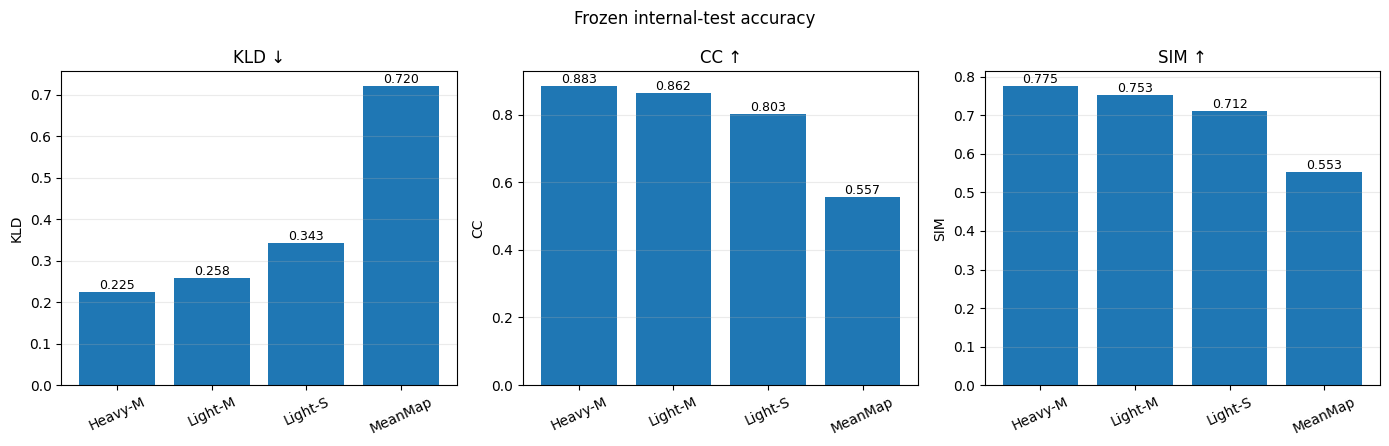

In [ ]:
metric_plot_specs = [
    ("kld", "KLD ↓", True),
    ("cc", "CC ↑", False),
    ("sim", "SIM ↑", False),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for axis, (metric, title, lower_is_better) in zip(
    axes,
    metric_plot_specs,
):
    ordered = final_metrics.sort_values(
        metric,
        ascending=lower_is_better,
    )

    axis.bar(ordered["label"], ordered[metric])
    axis.set_title(title)
    axis.set_ylabel(metric.upper())
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.25)

    for index, value in enumerate(ordered[metric]):
        axis.text(
            index,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle("Frozen internal-test accuracy")
fig.tight_layout()

fig.savefig(FINAL_METRIC_FIGURE_PATH, dpi=220, bbox_inches="tight")
fig.savefig(FINAL_METRIC_FIGURE_PDF_PATH, bbox_inches="tight")

plt.show()

In [ ]:
comparison_pairs = [
    ("light_multi", "light_single"),
    ("heavy_multi", "light_multi"),
    ("heavy_multi", "light_single"),
]

paired_rows = []

for first_model, second_model in comparison_pairs:
    first = full_per_image[first_model]
    second = full_per_image[second_model]

    merged = first.merge(
        second,
        on="sample_id",
        suffixes=("_first", "_second"),
        validate="one_to_one",
    )

    for metric in ("kld", "cc", "sim"):
        if metric == "kld":
            improvement = (
                merged[f"{metric}_second"]
                - merged[f"{metric}_first"]
            )
        else:
            improvement = (
                merged[f"{metric}_first"]
                - merged[f"{metric}_second"]
            )

        paired_rows.append(
            {
                "first_model": first_model,
                "second_model": second_model,
                "metric": metric,
                "mean_improvement": improvement.mean(),
                "median_improvement": improvement.median(),
                "standard_deviation": improvement.std(ddof=1),
                "fraction_images_first_better": (improvement > 0).mean(),
                "num_images": len(improvement),
            }
        )

paired_comparison = pd.DataFrame(paired_rows)
paired_comparison.to_csv(PAIRED_COMPARISON_PATH, index=False)

display(paired_comparison)

,first_model,second_model,metric,mean_improvement,median_improvement,standard_deviation,fraction_images_first_better,num_images
0,light_multi,light_single,kld,0.085120,0.069732,0.099457,0.8556,2500
1,light_multi,light_single,cc,0.059521,0.053029,0.059077,0.8792,2500
2,light_multi,light_single,sim,0.041532,0.037616,0.045576,0.8396,2500
3,heavy_multi,light_multi,kld,0.032992,0.031924,0.079157,0.7124,2500
4,heavy_multi,light_multi,cc,0.021089,0.019999,0.046862,0.7024,2500
5,heavy_multi,light_multi,sim,0.022291,0.021805,0.040955,0.7308,2500
6,heavy_multi,light_single,kld,0.118111,0.096582,0.126661,0.8812,2500
7,heavy_multi,light_single,cc,0.080610,0.074448,0.074950,0.8916,2500
8,heavy_multi,light_single,sim,0.063823,0.057437,0.061099,0.8808,2500


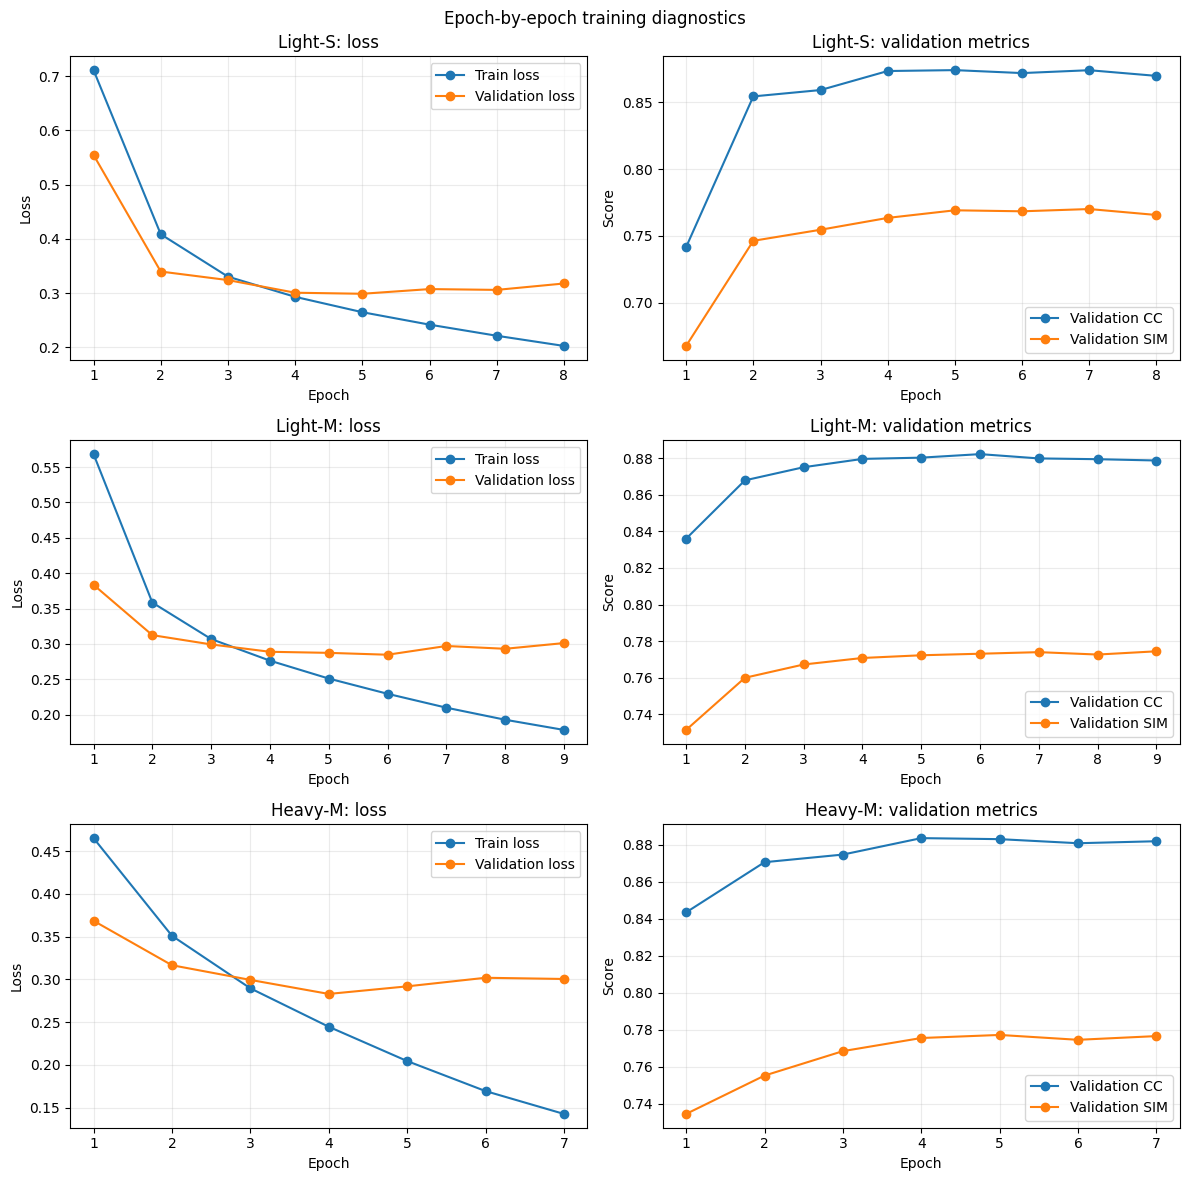

In [ ]:
history_paths = {
    "light_single": METRICS_ROOT / "light_single_history.csv",
    "light_multi": METRICS_ROOT / "light_multi_history.csv",
    "heavy_multi": METRICS_ROOT / "heavy_multi_history.csv",
}

available_histories = {
    model_name: pd.read_csv(path)
    for model_name, path in history_paths.items()
    if path.is_file()
}

if available_histories:
    fig, axes = plt.subplots(
        len(available_histories),
        2,
        figsize=(12, 4 * len(available_histories)),
        squeeze=False,
    )

    for row_index, (model_name, history) in enumerate(
        available_histories.items()
    ):
        label = method_labels[model_name]

        loss_axis = axes[row_index, 0]
        metric_axis = axes[row_index, 1]

        loss_axis.plot(
            history["epoch"],
            history["train_loss"],
            marker="o",
            label="Train loss",
        )
        loss_axis.plot(
            history["epoch"],
            history["val_loss"],
            marker="o",
            label="Validation loss",
        )
        loss_axis.set_title(f"{label}: loss")
        loss_axis.set_xlabel("Epoch")
        loss_axis.set_ylabel("Loss")
        loss_axis.grid(alpha=0.25)
        loss_axis.legend()

        metric_axis.plot(
            history["epoch"],
            history["val_cc"],
            marker="o",
            label="Validation CC",
        )
        metric_axis.plot(
            history["epoch"],
            history["val_sim"],
            marker="o",
            label="Validation SIM",
        )
        metric_axis.set_title(f"{label}: validation metrics")
        metric_axis.set_xlabel("Epoch")
        metric_axis.set_ylabel("Score")
        metric_axis.grid(alpha=0.25)
        metric_axis.legend()

    fig.suptitle("Epoch-by-epoch training diagnostics")
    fig.tight_layout()

    fig.savefig(
        TRAINING_CURVES_FIGURE_PATH,
        dpi=220,
        bbox_inches="tight",
    )
    fig.savefig(
        TRAINING_CURVES_FIGURE_PDF_PATH,
        bbox_inches="tight",
    )

    plt.show()
else:
    warnings.warn("No training-history CSV files were available.")

## Off-centre analysis

Build the top-quartile off-centre subset from the ground-truth maps and compare the score changes.


In [ ]:
def compute_target_geometry(dataloader: DataLoader) -> pd.DataFrame:
    records = []

    for batch in dataloader:
        batch_targets = batch["target"].float()
        batch_ids = [str(value) for value in batch["sample_id"]]

        _, _, height, width = batch_targets.shape

        x_coordinates = torch.linspace(
            0.0,
            1.0,
            width,
            dtype=batch_targets.dtype,
        ).view(1, 1, 1, width)

        y_coordinates = torch.linspace(
            0.0,
            1.0,
            height,
            dtype=batch_targets.dtype,
        ).view(1, 1, height, 1)

        centre_x = (batch_targets * x_coordinates).sum(
            dim=(1, 2, 3)
        )
        centre_y = (batch_targets * y_coordinates).sum(
            dim=(1, 2, 3)
        )

        centre_distance = torch.sqrt(
            (centre_x - 0.5).square()
            + (centre_y - 0.5).square()
        )

        for index, sample_id in enumerate(batch_ids):
            records.append(
                {
                    "sample_id": sample_id,
                    "target_centre_x": float(centre_x[index]),
                    "target_centre_y": float(centre_y[index]),
                    "centre_distance": float(centre_distance[index]),
                }
            )

    return pd.DataFrame(records)


ground_truth_geometry = compute_target_geometry(test_loader)
display(ground_truth_geometry.head())

,sample_id,target_centre_x,target_centre_y,centre_distance
0,100083,0.486906,0.400532,0.100327
1,100132,0.499844,0.444792,0.055208
2,100238,0.452160,0.323907,0.182476
3,100306,0.666946,0.644074,0.220519
4,100850,0.455366,0.438008,0.076388


In [ ]:
num_offcentre = max(
    1,
    math.ceil(len(ground_truth_geometry) * OFFCENTRE_FRACTION),
)

ground_truth_geometry = ground_truth_geometry.sort_values(
    "centre_distance",
    ascending=False,
).reset_index(drop=True)

ground_truth_geometry["offcentre_rank"] = (
    np.arange(len(ground_truth_geometry)) + 1
)
ground_truth_geometry["is_offcentre"] = (
    ground_truth_geometry["offcentre_rank"] <= num_offcentre
)

offcentre_ids = ground_truth_geometry.loc[
    ground_truth_geometry["is_offcentre"],
    "sample_id",
].astype(str).tolist()

OFFCENTRE_IDS_PATH.write_text(
    "\n".join(offcentre_ids) + "\n",
    encoding="utf-8",
)

ground_truth_geometry.to_csv(
    OFFCENTRE_GEOMETRY_PATH,
    index=False,
)

print(f"Selected off-centre samples: {len(offcentre_ids):,}")
print("Saved:", OFFCENTRE_IDS_PATH)

Selected off-centre samples: 625
Saved: /content/drive/MyDrive/saliency_project/splits/offcentre_test.txt


In [ ]:
test_id_to_index = {
    str(sample_id): index
    for index, sample_id in enumerate(
        test_dataset.manifest[ID_COLUMN].astype(str)
    )
}

missing_ids = [
    sample_id
    for sample_id in offcentre_ids
    if sample_id not in test_id_to_index
]

if missing_ids:
    raise RuntimeError(f"Missing off-centre IDs: {missing_ids[:10]}")

offcentre_indices = [
    test_id_to_index[sample_id]
    for sample_id in offcentre_ids
]

offcentre_dataset = Subset(test_dataset, offcentre_indices)

offcentre_loader = DataLoader(
    offcentre_dataset,
    shuffle=False,
    **common_loader_kwargs,
)

print(f"Off-centre samples: {len(offcentre_dataset):,}")
print(f"Off-centre batches: {len(offcentre_loader):,}")

Off-centre samples: 625
Off-centre batches: 79


In [ ]:
offcentre_summaries = {}
offcentre_per_image = {}

meanmap_off_summary, meanmap_off_records = evaluate_fixed_map(
    meanmap,
    offcentre_loader,
    DEVICE,
)

offcentre_summaries["meanmap"] = meanmap_off_summary
offcentre_per_image["meanmap"] = meanmap_off_records

for model_name, model in models.items():
    print("Evaluating:", MODEL_SPECS[model_name]["label"])

    summary, records = evaluate_model(
        model,
        offcentre_loader,
        DEVICE,
        use_amp=AMP_ENABLED,
        return_per_image=True,
    )

    offcentre_summaries[model_name] = summary
    offcentre_per_image[model_name] = pd.DataFrame(records)

    print(
        f"  KLD={summary['kld']:.6f} | "
        f"CC={summary['cc']:.6f} | "
        f"SIM={summary['sim']:.6f}"
    )

Evaluating: Light-S
  KLD=0.392787 | CC=0.804567 | SIM=0.689402
Evaluating: Light-M
  KLD=0.297532 | CC=0.868549 | SIM=0.733768
Evaluating: Heavy-M
  KLD=0.262321 | CC=0.887278 | SIM=0.755766


In [ ]:
centre_bias_rows = []

for method_name in full_summaries:
    full = full_summaries[method_name]
    offcentre = offcentre_summaries[method_name]

    centre_bias_rows.append(
        {
            "model": method_name,
            "label": method_labels[method_name],
            "full_kld": full["kld"],
            "offcentre_kld": offcentre["kld"],
            "kld_increase": offcentre["kld"] - full["kld"],
            "full_cc": full["cc"],
            "offcentre_cc": offcentre["cc"],
            "cc_drop": full["cc"] - offcentre["cc"],
            "full_sim": full["sim"],
            "offcentre_sim": offcentre["sim"],
            "sim_drop": full["sim"] - offcentre["sim"],
            "full_num_samples": int(full["num_samples"]),
            "offcentre_num_samples": int(offcentre["num_samples"]),
        }
    )

centre_bias_metrics = pd.DataFrame(centre_bias_rows)
centre_bias_metrics.to_csv(CENTRE_BIAS_METRICS_PATH, index=False)

display(
    centre_bias_metrics.sort_values(
        "offcentre_cc",
        ascending=False,
    )
)

,model,label,full_kld,offcentre_kld,kld_increase,full_cc,offcentre_cc,cc_drop,full_sim,offcentre_sim,sim_drop,full_num_samples,offcentre_num_samples
3,heavy_multi,Heavy-M,0.224665,0.262321,0.037656,0.883490,0.887278,-0.003789,0.775449,0.755766,0.019684,2500,625
2,light_multi,Light-M,0.257657,0.297532,0.039875,0.862401,0.868549,-0.006149,0.753158,0.733768,0.019390,2500,625
1,light_single,Light-S,0.342777,0.392787,0.050011,0.802880,0.804567,-0.001688,0.711626,0.689402,0.022225,2500,625
0,meanmap,MeanMap,0.720233,1.007342,0.287109,0.556980,0.431390,0.125590,0.552755,0.458464,0.094291,2500,625


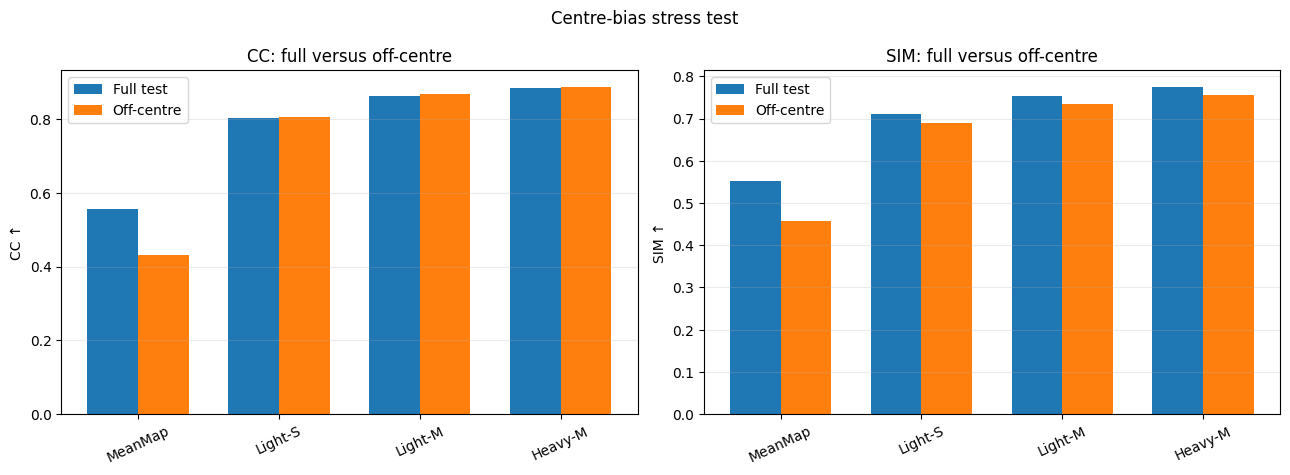

In [ ]:
labels = centre_bias_metrics["label"].tolist()
x_positions = np.arange(len(labels))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].bar(
    x_positions - bar_width / 2,
    centre_bias_metrics["full_cc"],
    width=bar_width,
    label="Full test",
)
axes[0].bar(
    x_positions + bar_width / 2,
    centre_bias_metrics["offcentre_cc"],
    width=bar_width,
    label="Off-centre",
)
axes[0].set_title("CC: full versus off-centre")
axes[0].set_ylabel("CC ↑")
axes[0].set_xticks(x_positions, labels, rotation=25)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

axes[1].bar(
    x_positions - bar_width / 2,
    centre_bias_metrics["full_sim"],
    width=bar_width,
    label="Full test",
)
axes[1].bar(
    x_positions + bar_width / 2,
    centre_bias_metrics["offcentre_sim"],
    width=bar_width,
    label="Off-centre",
)
axes[1].set_title("SIM: full versus off-centre")
axes[1].set_ylabel("SIM ↑")
axes[1].set_xticks(x_positions, labels, rotation=25)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

fig.suptitle("Centre-bias stress test")
fig.tight_layout()

fig.savefig(CENTRE_BIAS_FIGURE_PATH, dpi=220, bbox_inches="tight")
fig.savefig(CENTRE_BIAS_FIGURE_PDF_PATH, bbox_inches="tight")

plt.show()

## Qualitative examples

Select fixed cases from the per-image scores and save the aligned prediction panel.


## 38. Merge per-image scores and select unique cases

In [ ]:
MANUAL_SAMPLE_IDS = []

selection_scores = ground_truth_geometry[
    [
        "sample_id",
        "target_centre_x",
        "target_centre_y",
        "centre_distance",
        "is_offcentre",
    ]
].copy()

for model_name in ("light_single", "light_multi", "heavy_multi"):
    model_scores = full_per_image[model_name][
        ["sample_id", "kld", "cc", "sim"]
    ].rename(
        columns={
            "kld": f"{model_name}_kld",
            "cc": f"{model_name}_cc",
            "sim": f"{model_name}_sim",
        }
    )

    selection_scores = selection_scores.merge(
        model_scores,
        on="sample_id",
        validate="one_to_one",
    )

selection_scores["light_multi_gain_vs_light_single_cc"] = (
    selection_scores["light_multi_cc"]
    - selection_scores["light_single_cc"]
)


def choose_first_unused(
    case_name: str,
    ordered_ids: list[str],
    used_ids: set[str],
    selected_rows: list[dict],
) -> None:
    for sample_id in ordered_ids:
        sample_id = str(sample_id)

        if sample_id not in used_ids:
            used_ids.add(sample_id)
            selected_rows.append(
                {"case": case_name, "sample_id": sample_id}
            )
            return

    raise RuntimeError(f"No unique sample found for {case_name}.")


selected_rows = []
used_ids = set()

if MANUAL_SAMPLE_IDS:
    for position, sample_id in enumerate(MANUAL_SAMPLE_IDS, start=1):
        choose_first_unused(
            f"manual_{position}",
            [str(sample_id)],
            used_ids,
            selected_rows,
        )
else:
    choose_first_unused(
        "most_central",
        selection_scores.sort_values("centre_distance")[
            "sample_id"
        ].tolist(),
        used_ids,
        selected_rows,
    )

    choose_first_unused(
        "most_offcentre",
        selection_scores.sort_values(
            "centre_distance",
            ascending=False,
        )["sample_id"].tolist(),
        used_ids,
        selected_rows,
    )

    median_cc = selection_scores["light_multi_cc"].median()
    median_order = (
        selection_scores.assign(
            median_distance=(
                selection_scores["light_multi_cc"] - median_cc
            ).abs()
        )
        .sort_values("median_distance")["sample_id"]
        .tolist()
    )

    choose_first_unused(
        "median_light_m",
        median_order,
        used_ids,
        selected_rows,
    )

    choose_first_unused(
        "worst_light_m",
        selection_scores.sort_values("light_multi_cc")[
            "sample_id"
        ].tolist(),
        used_ids,
        selected_rows,
    )

    choose_first_unused(
        "largest_light_m_gain",
        selection_scores.sort_values(
            "light_multi_gain_vs_light_single_cc",
            ascending=False,
        )["sample_id"].tolist(),
        used_ids,
        selected_rows,
    )

selected_examples = pd.DataFrame(selected_rows).merge(
    selection_scores,
    on="sample_id",
    validate="one_to_one",
)

selected_examples.to_csv(SELECTED_EXAMPLES_PATH, index=False)
display(selected_examples)

,case,sample_id,target_centre_x,target_centre_y,centre_distance,is_offcentre,light_single_kld,light_single_cc,light_single_sim,light_multi_kld,light_multi_cc,light_multi_sim,heavy_multi_kld,heavy_multi_cc,heavy_multi_sim,light_multi_gain_vs_light_single_cc
0,most_central,166320,0.497869,0.500321,0.002155,False,0.269600,0.592369,0.723114,0.198558,0.699151,0.765766,0.125199,0.820701,0.814848,0.106782
1,most_offcentre,268435,0.664530,0.795124,0.337888,True,0.868607,0.772906,0.482089,0.917835,0.895019,0.415481,0.964910,0.849558,0.399940,0.122113
2,median_light_m,164330,0.450797,0.456499,0.065676,False,0.433572,0.806891,0.667253,0.340281,0.873283,0.705369,0.294270,0.894716,0.738832,0.066392
3,worst_light_m,488346,0.647391,0.474951,0.149504,True,0.809070,0.553080,0.536375,1.095039,0.468742,0.494983,0.478464,0.773953,0.639592,-0.084338
4,largest_light_m_gain,350073,0.496778,0.667274,0.167306,True,0.980526,0.429262,0.444096,0.396464,0.802659,0.664176,0.141744,0.942155,0.819751,0.373397


In [ ]:
imagenet_mean_tensor = torch.tensor(
    IMAGENET_MEAN,
    dtype=torch.float32,
).view(3, 1, 1)

imagenet_std_tensor = torch.tensor(
    IMAGENET_STD,
    dtype=torch.float32,
).view(3, 1, 1)


def denormalize_rgb(image_tensor: torch.Tensor) -> np.ndarray:
    image = (
        image_tensor.detach().cpu() * imagenet_std_tensor
        + imagenet_mean_tensor
    )
    image = image.clamp(0.0, 1.0)
    return image.permute(1, 2, 0).numpy()


@torch.inference_mode()
def predict_sample(
    model: torch.nn.Module,
    image_tensor: torch.Tensor,
) -> torch.Tensor:
    logits = model(
        image_tensor.unsqueeze(0).to(
            DEVICE,
            non_blocking=True,
        )
    )
    prediction = spatial_softmax(logits)
    return prediction[0, 0].detach().cpu()

In [ ]:
qualitative_records = []

for selected_row in selected_examples.itertuples(index=False):
    sample_id = str(selected_row.sample_id)
    sample = test_dataset[test_id_to_index[sample_id]]

    record = {
        "case": selected_row.case,
        "sample_id": sample_id,
        "rgb": denormalize_rgb(sample["image"]),
        "ground_truth": sample["target"][0].detach().cpu(),
        "meanmap": meanmap[0].detach().cpu(),
    }

    for model_name, model in models.items():
        record[model_name] = predict_sample(
            model,
            sample["image"],
        )

    qualitative_records.append(record)

print(f"Generated {len(qualitative_records)} qualitative rows.")

Generated 5 qualitative rows.


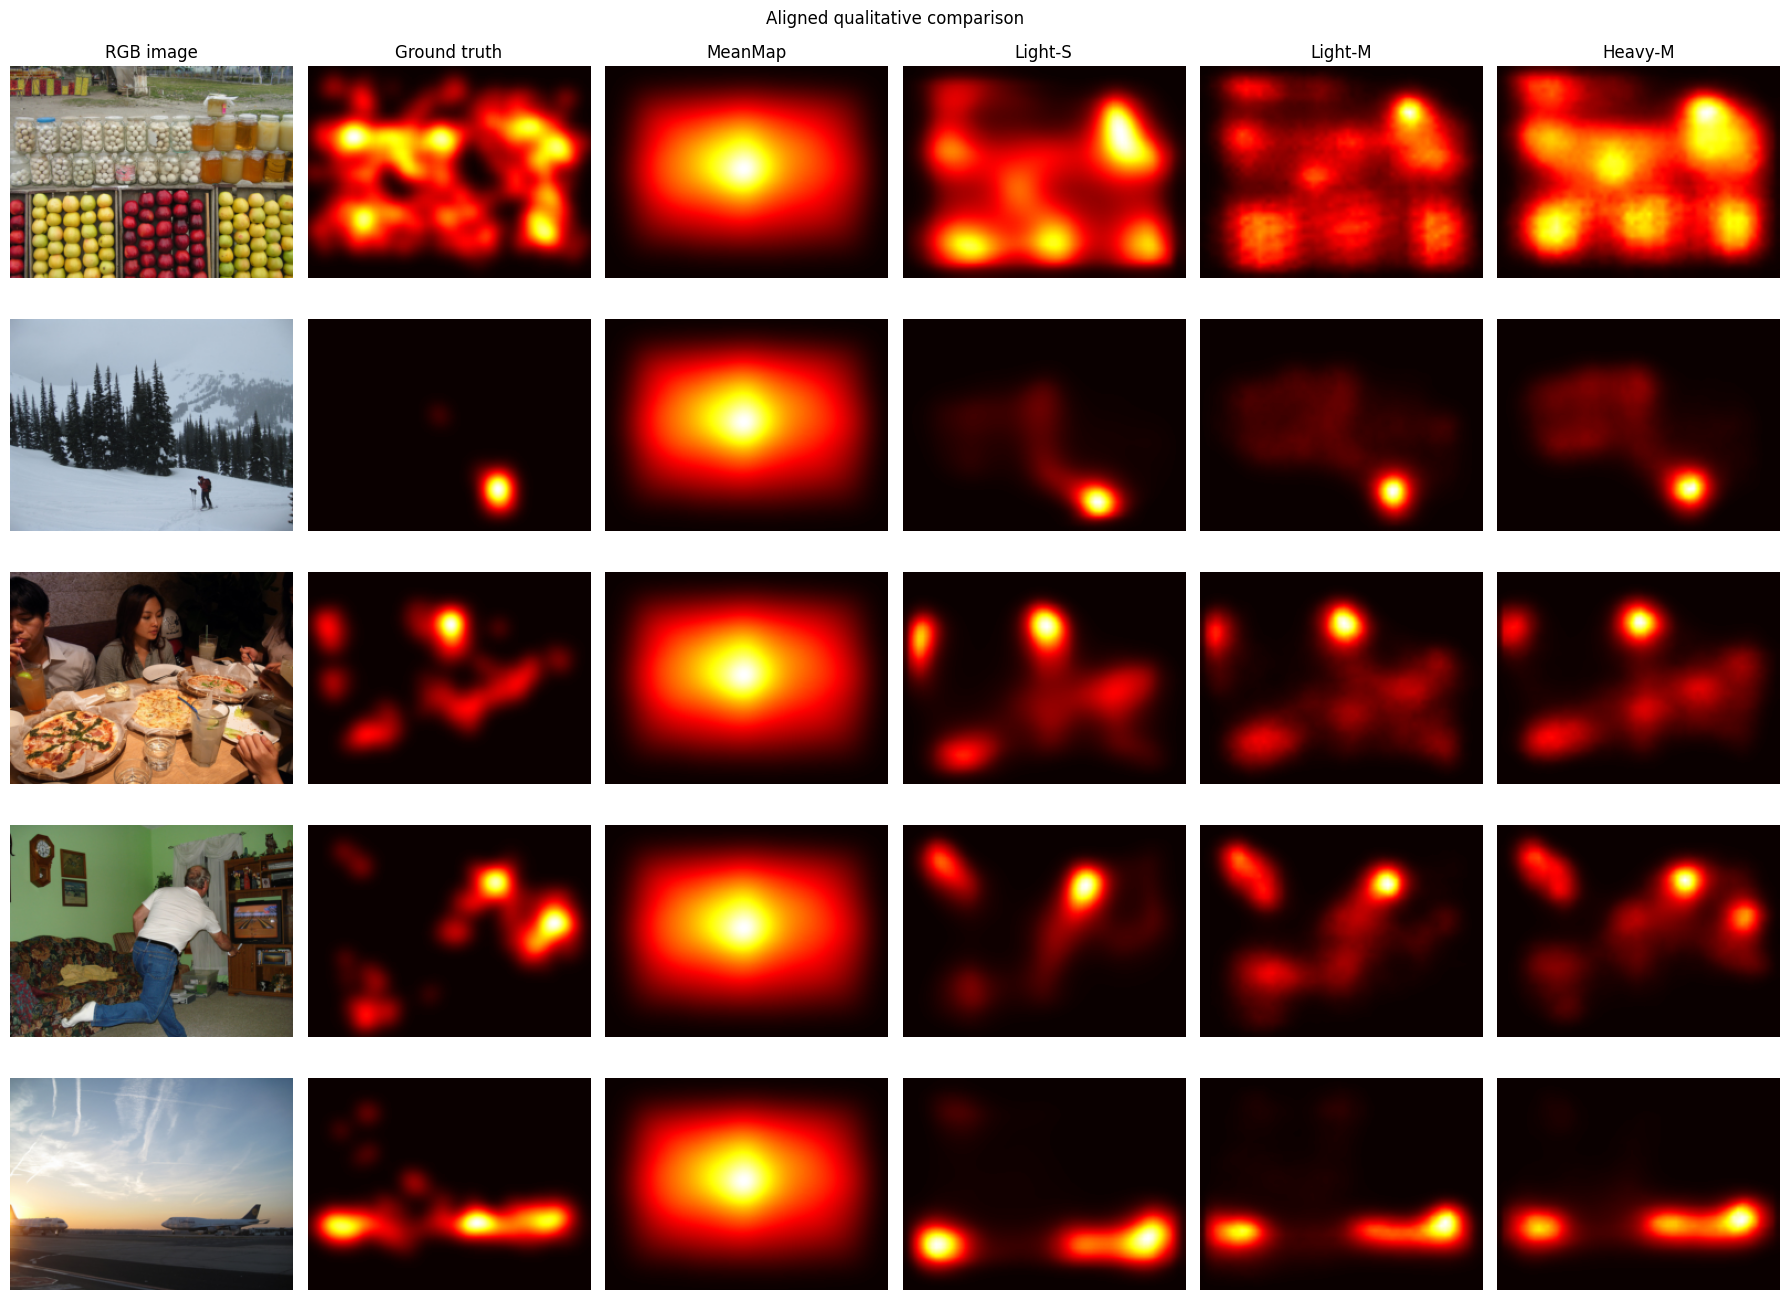

In [ ]:
qualitative_columns = [
    ("rgb", "RGB image"),
    ("ground_truth", "Ground truth"),
    ("meanmap", "MeanMap"),
    ("light_single", "Light-S"),
    ("light_multi", "Light-M"),
    ("heavy_multi", "Heavy-M"),
]

num_rows = len(qualitative_records)
num_columns = len(qualitative_columns)

fig, axes = plt.subplots(
    num_rows,
    num_columns,
    figsize=(3.0 * num_columns, 2.7 * num_rows),
    squeeze=False,
)

for row_index, record in enumerate(qualitative_records):
    for column_index, (key, title) in enumerate(
        qualitative_columns
    ):
        axis = axes[row_index, column_index]

        if key == "rgb":
            axis.imshow(record[key])
        else:
            axis.imshow(record[key], cmap="hot")

        axis.axis("off")

        if row_index == 0:
            axis.set_title(title)

        if column_index == 0:
            axis.set_ylabel(
                f"{record['case']}\n{record['sample_id']}",
                rotation=0,
                labelpad=55,
                va="center",
            )

fig.suptitle("Aligned qualitative comparison")
fig.tight_layout()

fig.savefig(QUALITATIVE_FIGURE_PATH, dpi=220, bbox_inches="tight")
fig.savefig(QUALITATIVE_FIGURE_PDF_PATH, bbox_inches="tight")

plt.show()

In [ ]:
for record in qualitative_records:
    sample_root = (
        PREDICTION_ROOT
        / f"{record['case']}__{record['sample_id']}"
    )
    sample_root.mkdir(parents=True, exist_ok=True)

    plt.imsave(sample_root / "rgb.png", record["rgb"])

    for key, _ in qualitative_columns[1:]:
        plt.imsave(
            sample_root / f"{key}.png",
            record[key],
            cmap="hot",
        )

print("Saved selected predictions under:", PREDICTION_ROOT)

Saved selected predictions under: /content/drive/MyDrive/saliency_project/outputs/predictions/final_selected


## Efficiency

Measure model size, operations and CPU latency, then combine them with the accuracy results.


In [ ]:
def state_dict_size_bytes(model: torch.nn.Module) -> int:
    total_bytes = 0

    for value in model.state_dict().values():
        if isinstance(value, torch.Tensor):
            total_bytes += value.numel() * value.element_size()

    return total_bytes


def read_cpu_name() -> str:
    cpuinfo_path = Path("/proc/cpuinfo")

    if cpuinfo_path.is_file():
        for line in cpuinfo_path.read_text(
            encoding="utf-8",
            errors="ignore",
        ).splitlines():
            if line.lower().startswith("model name"):
                return line.split(":", 1)[1].strip()

    return platform.processor() or "unknown"

In [ ]:
from thop import profile


def profile_model_operations(
    model: torch.nn.Module,
    input_shape: tuple[int, int, int, int],
) -> tuple[float, float]:
    model.eval()
    dummy_input = torch.zeros(input_shape, dtype=torch.float32)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        macs, _ = profile(
            model,
            inputs=(dummy_input,),
            verbose=False,
        )

    return float(macs), float(2.0 * macs)

In [ ]:
def benchmark_cpu_latency(
    model: torch.nn.Module,
    input_shape: tuple[int, int, int, int],
    *,
    warmup: int,
    runs: int,
    repeats: int,
    num_threads: int,
) -> dict[str, object]:
    previous_threads = torch.get_num_threads()
    torch.set_num_threads(num_threads)

    model.eval()
    dummy_input = torch.randn(input_shape, dtype=torch.float32)

    repeat_medians = []
    repeat_p90s = []

    try:
        with torch.inference_mode():
            for _ in range(warmup):
                model(dummy_input)

            for _ in range(repeats):
                timings_ms = []

                for _ in range(runs):
                    start = time.perf_counter_ns()
                    model(dummy_input)
                    end = time.perf_counter_ns()

                    timings_ms.append((end - start) / 1_000_000.0)

                repeat_medians.append(float(np.median(timings_ms)))
                repeat_p90s.append(
                    float(np.percentile(timings_ms, 90))
                )
    finally:
        torch.set_num_threads(previous_threads)

    median_ms = float(np.median(repeat_medians))
    p90_ms = float(np.median(repeat_p90s))

    return {
        "cpu_median_ms": median_ms,
        "cpu_p90_ms": p90_ms,
        "cpu_fps_from_median": 1000.0 / median_ms,
        "repeat_medians_ms": repeat_medians,
        "repeat_p90s_ms": repeat_p90s,
    }

In [ ]:
efficiency_rows = []
input_shape = (1, 3, OUTPUT_SIZE[0], OUTPUT_SIZE[1])
cpu_name = read_cpu_name()

for model_name, model in models.items():
    label = MODEL_SPECS[model_name]["label"]
    checkpoint_path = MODEL_SPECS[model_name]["checkpoint"]

    print(f"Profiling {label}...")

    model_cpu = model.to("cpu").eval()
    models[model_name] = model_cpu

    counts = parameter_summary(model_cpu)
    state_bytes = state_dict_size_bytes(model_cpu)

    try:
        macs, flops = profile_model_operations(
            model_cpu,
            input_shape,
        )
        profiler_error = None
    except Exception as error:
        macs = float("nan")
        flops = float("nan")
        profiler_error = repr(error)
        warnings.warn(f"Profiling failed for {model_name}: {error}")

    latency = benchmark_cpu_latency(
        model_cpu,
        input_shape,
        warmup=LATENCY_WARMUP,
        runs=LATENCY_RUNS,
        repeats=LATENCY_REPEATS,
        num_threads=LATENCY_THREADS,
    )

    efficiency_rows.append(
        {
            "model": model_name,
            "label": label,
            "encoder_parameters": counts["encoder"],
            "decoder_parameters": counts["decoder"],
            "total_parameters": counts["total"],
            "trainable_parameters": counts["trainable"],
            "total_parameters_millions": counts["total"] / 1_000_000,
            "state_dict_mb": state_bytes / (1024 ** 2),
            "checkpoint_file_mb": (
                checkpoint_path.stat().st_size / (1024 ** 2)
            ),
            "macs": macs,
            "macs_giga": macs / 1_000_000_000,
            "flops": flops,
            "flops_giga": flops / 1_000_000_000,
            "cpu_median_ms": latency["cpu_median_ms"],
            "cpu_p90_ms": latency["cpu_p90_ms"],
            "cpu_fps_from_median": latency["cpu_fps_from_median"],
            "latency_threads": LATENCY_THREADS,
            "latency_warmup": LATENCY_WARMUP,
            "latency_runs_per_repeat": LATENCY_RUNS,
            "latency_repeats": LATENCY_REPEATS,
            "latency_repeat_medians_ms": json.dumps(
                latency["repeat_medians_ms"]
            ),
            "latency_repeat_p90s_ms": json.dumps(
                latency["repeat_p90s_ms"]
            ),
            "input_shape": str(input_shape),
            "mac_flop_convention": "FLOPs = 2 x MACs",
            "profiler_error": profiler_error,
            "cpu_name": cpu_name,
            "pytorch_version": torch.__version__,
        }
    )

    print(
        f"  params={counts['total'] / 1e6:.3f} M | "
        f"MACs={macs / 1e9:.3f} G | "
        f"median={latency['cpu_median_ms']:.3f} ms"
    )

Profiling Light-S...
  params=1.826 M | MACs=0.306 G | median=23.782 ms
Profiling Light-M...
  params=1.831 M | MACs=0.309 G | median=30.626 ms
Profiling Heavy-M...
  params=11.211 M | MACs=1.803 G | median=61.859 ms


In [ ]:
efficiency_metrics = pd.DataFrame(efficiency_rows)
efficiency_metrics.to_csv(EFFICIENCY_METRICS_PATH, index=False)

display(
    efficiency_metrics[
        [
            "label",
            "total_parameters_millions",
            "state_dict_mb",
            "macs_giga",
            "flops_giga",
            "cpu_median_ms",
            "cpu_p90_ms",
            "cpu_fps_from_median",
        ]
    ].sort_values("cpu_median_ms")
)

,label,total_parameters_millions,state_dict_mb,macs_giga,flops_giga,cpu_median_ms,cpu_p90_ms,cpu_fps_from_median
0,Light-S,1.826113,7.086819,0.305523,0.611045,23.781522,37.660193,42.049454
1,Light-M,1.830977,7.105373,0.309258,0.618516,30.626172,39.013200,32.651811
2,Heavy-M,11.211393,42.804844,1.803467,3.606934,61.858660,85.930616,16.165885


In [ ]:
final_report_table = final_metrics.merge(
    efficiency_metrics[
        [
            "model",
            "total_parameters",
            "total_parameters_millions",
            "state_dict_mb",
            "checkpoint_file_mb",
            "macs_giga",
            "flops_giga",
            "cpu_median_ms",
            "cpu_p90_ms",
            "cpu_fps_from_median",
        ]
    ],
    on="model",
    how="left",
)

meanmap_mask = final_report_table["model"] == "meanmap"

final_report_table.loc[
    meanmap_mask,
    [
        "total_parameters",
        "total_parameters_millions",
        "state_dict_mb",
        "checkpoint_file_mb",
        "macs_giga",
        "flops_giga",
    ],
] = 0.0

final_report_table.to_csv(FINAL_REPORT_TABLE_PATH, index=False)

display(final_report_table)

,model,label,loss,kld,cc,sim,num_samples,num_batches,evaluation_seconds,total_parameters,total_parameters_millions,state_dict_mb,checkpoint_file_mb,macs_giga,flops_giga,cpu_median_ms,cpu_p90_ms,cpu_fps_from_median
0,meanmap,MeanMap,0.941743,0.720233,0.556980,0.552755,2500,313,26.329323,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,light_single,Light-S,0.441979,0.342777,0.802880,0.711626,2500,313,38.565879,1826113.0,1.826113,7.086819,21.267591,0.305523,0.611045,23.781522,37.660193,42.049454
2,light_multi,Light-M,0.326949,0.257657,0.862401,0.753158,2500,313,29.410441,1830977.0,1.830977,7.105373,21.327443,0.309258,0.618516,30.626172,39.013200,32.651811
3,heavy_multi,Heavy-M,0.283420,0.224665,0.883490,0.775449,2500,313,29.001544,11211393.0,11.211393,42.804844,128.452964,1.803467,3.606934,61.858660,85.930616,16.165885


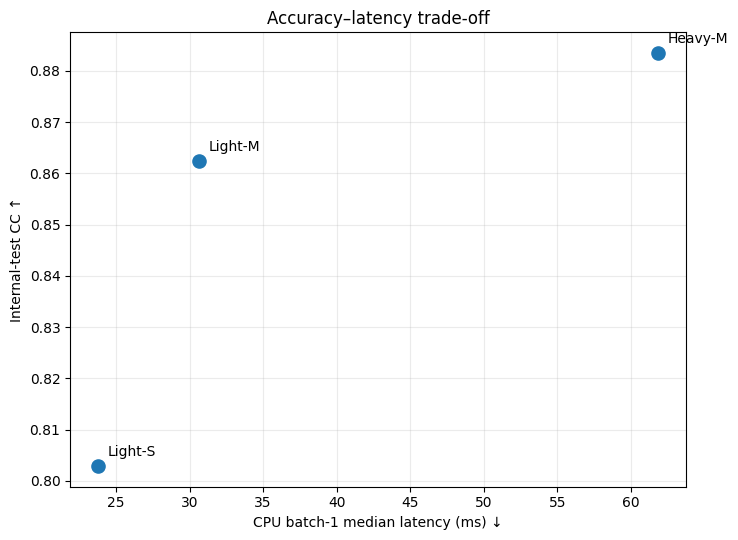

In [ ]:
pareto_data = final_report_table[
    final_report_table["model"] != "meanmap"
].copy()

fig, axis = plt.subplots(figsize=(7.5, 5.5))

axis.scatter(
    pareto_data["cpu_median_ms"],
    pareto_data["cc"],
    s=90,
)

for row in pareto_data.itertuples(index=False):
    axis.annotate(
        row.label,
        (row.cpu_median_ms, row.cc),
        xytext=(7, 7),
        textcoords="offset points",
    )

axis.set_xlabel("CPU batch-1 median latency (ms) ↓")
axis.set_ylabel("Internal-test CC ↑")
axis.set_title("Accuracy–latency trade-off")
axis.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(PARETO_FIGURE_PATH, dpi=220, bbox_inches="tight")
fig.savefig(PARETO_FIGURE_PDF_PATH, bbox_inches="tight")

plt.show()

## Saved summary

Store the environment information and the numerical summary used for the report.


In [ ]:
environment_record = {
    "status": "completed",
    "git_commit": commit_hash,
    "temporary_source_patch_notes": source_patch_notes,
    "seed": SEED,
    "device_used_for_accuracy": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "cpu_name": cpu_name,
    "python_version": platform.python_version(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "output_size": list(OUTPUT_SIZE),
    "decoder_channels": DECODER_CHANNELS,
    "test_manifest_source": str(SOURCE_TEST_MANIFEST),
    "test_manifest_sha256": TEST_MANIFEST_HASH,
    "test_num_samples": len(test_dataset),
    "offcentre_fraction": OFFCENTRE_FRACTION,
    "offcentre_num_samples": len(offcentre_dataset),
    "evaluation_batch_size": EVAL_BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "amp_requested": USE_AMP,
    "amp_active": AMP_ENABLED,
    "training_data_root": str(TRAINING_DATA_ROOT),
    "latency_protocol": {
        "threads": LATENCY_THREADS,
        "warmup": LATENCY_WARMUP,
        "runs_per_repeat": LATENCY_RUNS,
        "repeats": LATENCY_REPEATS,
        "scope": "model forward only",
    },
    "checkpoint_metadata": checkpoint_metadata,
}

with ENVIRONMENT_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(environment_record, file, indent=2)

print("Saved:", ENVIRONMENT_JSON_PATH)

Saved: /content/drive/MyDrive/saliency_project/logs/run_notes/final_evaluation_environment.json


In [ ]:
metrics_by_model = final_metrics.set_index("model")
bias_by_model = centre_bias_metrics.set_index("model")
efficiency_by_model = efficiency_metrics.set_index("model")

best_kld_model = metrics_by_model["kld"].idxmin()
best_cc_model = metrics_by_model["cc"].idxmax()
best_sim_model = metrics_by_model["sim"].idxmax()
fastest_model = efficiency_by_model["cpu_median_ms"].idxmin()

light_m_vs_light_s = {
    "kld_change": (
        metrics_by_model.loc["light_multi", "kld"]
        - metrics_by_model.loc["light_single", "kld"]
    ),
    "cc_change": (
        metrics_by_model.loc["light_multi", "cc"]
        - metrics_by_model.loc["light_single", "cc"]
    ),
    "sim_change": (
        metrics_by_model.loc["light_multi", "sim"]
        - metrics_by_model.loc["light_single", "sim"]
    ),
    "latency_change_ms": (
        efficiency_by_model.loc["light_multi", "cpu_median_ms"]
        - efficiency_by_model.loc["light_single", "cpu_median_ms"]
    ),
}

heavy_m_vs_light_m = {
    "kld_change": (
        metrics_by_model.loc["heavy_multi", "kld"]
        - metrics_by_model.loc["light_multi", "kld"]
    ),
    "cc_change": (
        metrics_by_model.loc["heavy_multi", "cc"]
        - metrics_by_model.loc["light_multi", "cc"]
    ),
    "sim_change": (
        metrics_by_model.loc["heavy_multi", "sim"]
        - metrics_by_model.loc["light_multi", "sim"]
    ),
    "latency_change_ms": (
        efficiency_by_model.loc["heavy_multi", "cpu_median_ms"]
        - efficiency_by_model.loc["light_multi", "cpu_median_ms"]
    ),
}

summary_record = {
    "best_test_kld_model": best_kld_model,
    "best_test_cc_model": best_cc_model,
    "best_test_sim_model": best_sim_model,
    "fastest_neural_model": fastest_model,
    "light_multi_minus_light_single": light_m_vs_light_s,
    "heavy_multi_minus_light_multi": heavy_m_vs_light_m,
    "centre_bias_cc_drops": bias_by_model["cc_drop"].to_dict(),
    "centre_bias_sim_drops": bias_by_model["sim_drop"].to_dict(),
}

with SUMMARY_JSON_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary_record, file, indent=2)

summary_lines = [
    "# Final evaluation summary",
    "",
    (
        f"- Best test KLD: **{method_labels[best_kld_model]}** "
        f"({metrics_by_model.loc[best_kld_model, 'kld']:.6f})"
    ),
    (
        f"- Best test CC: **{method_labels[best_cc_model]}** "
        f"({metrics_by_model.loc[best_cc_model, 'cc']:.6f})"
    ),
    (
        f"- Best test SIM: **{method_labels[best_sim_model]}** "
        f"({metrics_by_model.loc[best_sim_model, 'sim']:.6f})"
    ),
    (
        f"- Fastest neural model: **{method_labels[fastest_model]}** "
        f"({efficiency_by_model.loc[fastest_model, 'cpu_median_ms']:.3f} ms)"
    ),
    "",
    "## Light-M compared with Light-S",
    "",
    f"- KLD change: {light_m_vs_light_s['kld_change']:+.6f} (negative is better)",
    f"- CC change: {light_m_vs_light_s['cc_change']:+.6f}",
    f"- SIM change: {light_m_vs_light_s['sim_change']:+.6f}",
    f"- CPU latency change: {light_m_vs_light_s['latency_change_ms']:+.3f} ms",
    "",
    "## Heavy-M compared with Light-M",
    "",
    f"- KLD change: {heavy_m_vs_light_m['kld_change']:+.6f} (negative is better)",
    f"- CC change: {heavy_m_vs_light_m['cc_change']:+.6f}",
    f"- SIM change: {heavy_m_vs_light_m['sim_change']:+.6f}",
    f"- CPU latency change: {heavy_m_vs_light_m['latency_change_ms']:+.3f} ms",
    "",
    (
        "These values describe this frozen SALICON split and documented "
        "runtime. The report should discuss trade-offs and failure cases "
        "rather than claim universal superiority."
    ),
]

summary_markdown = "\n".join(summary_lines)

SUMMARY_MD_PATH.write_text(
    summary_markdown + "\n",
    encoding="utf-8",
)

display(Markdown(summary_markdown))
print("Saved:", SUMMARY_JSON_PATH)
print("Saved:", SUMMARY_MD_PATH)

# Final evaluation summary

- Best test KLD: **Heavy-M** (0.224665)
- Best test CC: **Heavy-M** (0.883490)
- Best test SIM: **Heavy-M** (0.775449)
- Fastest neural model: **Light-S** (23.782 ms)

## Light-M compared with Light-S

- KLD change: -0.085120 (negative is better)
- CC change: +0.059521
- SIM change: +0.041532
- CPU latency change: +6.845 ms

## Heavy-M compared with Light-M

- KLD change: -0.032992 (negative is better)
- CC change: +0.021089
- SIM change: +0.022291
- CPU latency change: +31.232 ms

These values describe this frozen SALICON split and documented runtime. The report should discuss trade-offs and failure cases rather than claim universal superiority.

Saved: /content/drive/MyDrive/saliency_project/logs/run_notes/final_evaluation_summary.json
Saved: /content/drive/MyDrive/saliency_project/logs/run_notes/final_evaluation_summary.md


## Result

Heavy-M obtained the best test scores: KLD `0.224665`, CC `0.883490` and SIM `0.775449`.

Light-M stayed close while using only `1.831M` parameters and a median CPU latency of `30.626 ms`. Compared with Light-S, it improved CC by `0.059521` and SIM by `0.041532` with almost the same model size.

The MeanMap baseline dropped strongly on the off-centre subset, while the three learned models were much more stable. The final tables, figures and selected predictions were saved to Google Drive.
